### Маркетинговое A/B тестирование

Ссылка на датасет: [Kaggle](https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing)

Онлайн версия данного блокнота: [Google Colab](https://colab.research.google.com/drive/1HIk4TKSFv7yV6Y8Y8bf65ac_qVoCluDd?usp=sharing)

#### План
1. Выгрузить датасет
2. Провести разведочный анализ данных (EDA)
3. Подобрать метрики и сформулировать гипотезы, провести анализ данных
4. Сделать выводы, повлиял ли показ рекламы на конверсию

#### Описание столбцов в таблице датасета
  
| Столбец | Описание |
|---|---|
| user id | Уникальный ID пользователя |
| test group | Группа пользователя: "ad" - если пользователю показали рекламу, "psa" - если пользователю вместо рекламы показали некоммерческое объявление|
| converted | Купил ли пользователь показанный в рекламе товар (Ложь либо Истина) |
| total ads | Количество показов рекламы пользователю |
| most ads day | День недели, когда пользователю показывали рекламу чаще всего |
| most ads hour | Час дня, в который пользователю чаще всего показывали рекламу |

#### 1. Выгрузка и обработка датасета

In [2]:
# Игнорируем некритичные предупреждения python
from warnings import simplefilter
simplefilter("ignore")

# Выгружаем датасет в датафрейм
import pandas as pd

df = pd.read_csv('dataset/marketing_AB.csv')

df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [ ]:
# Удаляем ненужные столбцы - столбец индексов и столбец "user id", т. к. перед нами не стоит задачи поиска конкретных пользователей, а только оценка влияния маркетинга на разные группы
df.drop(columns=['Unnamed: 0', 'user id'], inplace=True)

df.head()

,test group,converted,total ads,most ads day,most ads hour
0,ad,False,130,Monday,20
1,ad,False,93,Tuesday,22
2,ad,False,21,Tuesday,18
3,ad,False,355,Tuesday,10
4,ad,False,276,Friday,14


#### 2. Разведочный анализ (EDA)

In [13]:
# Размер датасета и информация о столбцах
print(f"В датасете {df.shape[0]} строк и {df.shape[1]} столбцов")

print(f"В датасете {df.isna().sum().sum()} пустых значений")

print(df.info())

В датасете 588101 строк и 5 столбцов
В датасете 0 пустых значений
<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   test group     588101 non-null  str  
 1   converted      588101 non-null  bool 
 2   total ads      588101 non-null  int64
 3   most ads day   588101 non-null  str  
 4   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(2), str(2)
memory usage: 18.5 MB
None


In [9]:
# Краткая статистика по числовым столбцам
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total ads,588101.0,24.820876,43.715181,1.0,4.0,13.0,27.0,2065.0
most ads hour,588101.0,14.469061,4.834634,0.0,11.0,14.0,18.0,23.0


In [16]:
# Уникальные значения в нечисловых столбцах
print("Test group:", df['test group'].unique())
print("Converted:", df['converted'].unique())
print("Most ads day:", df['most ads day'].unique())

Test group: <StringArray>
['ad', 'psa']
Length: 2, dtype: str
Converted: [False  True]
Most ads day: <StringArray>
['Monday', 'Tuesday', 'Friday', 'Saturday', 'Wednesday', 'Sunday', 'Thursday']
Length: 7, dtype: str


#### 3. Подобор метрик и формулировка гипотез, проведение анализа

Основной метрикой, на которую мы будем ориентироваться, будет конверсия (Conversion Rate), расчёт которой будет основан на столбце "converted".

Далее мы проверим, как меняется конверсия в зависимости от дня недели и часа дня. 

За нулевую гипотезу возьмём утверждение, что показ рекламы не влияет на конверсию.

In [ ]:
# Столбец "Converted" нужно привести из булевого типа в целочисленный
df['converted'] = df['converted'].astype(int)

df.dtypes

test group         str
converted        int64
total ads        int64
most ads day       str
most ads hour    int64
dtype: object

In [20]:
df['converted'].unique()

array([0, 1])

In [21]:
df['converted']

0         0
1         0
2         0
3         0
4         0
         ..
588096    0
588097    0
588098    0
588099    0
588100    0
Name: converted, Length: 588101, dtype: int64

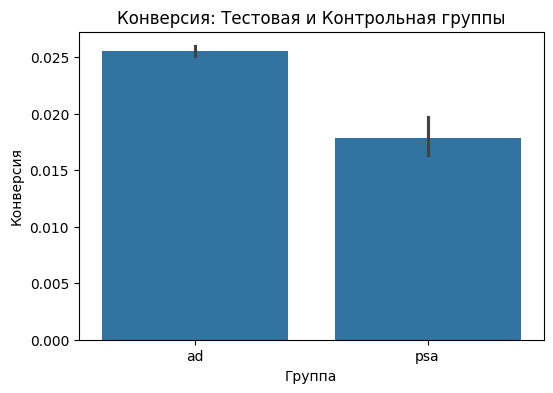

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Строим гистограмму соотношения конверсий тестовой (ad) и контрольной (psa) групп
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='test group', y='converted')
plt.title("Конверсия: Тестовая и Контрольная группы")
plt.xlabel("Группа")
plt.ylabel("Конверсия")
plt.show()

На первый взгляд, конверсия у тестовой группы выше, чем у контрольной

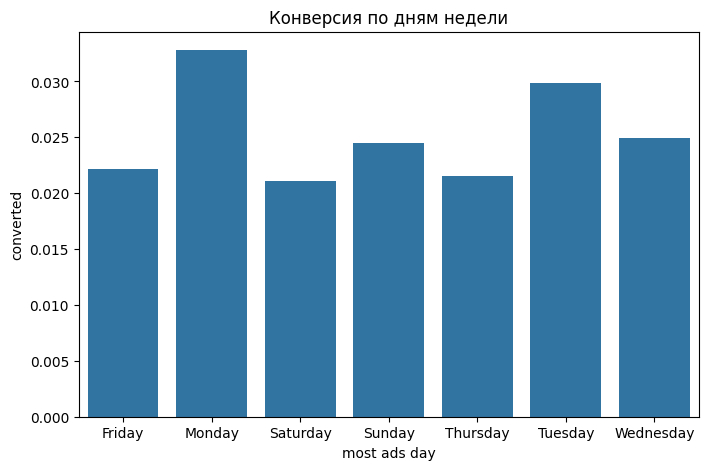

In [33]:
# Строим гистограмму конверсий по дням недели
day_rate = df.groupby('most ads day')['converted'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=day_rate, x='most ads day', y='converted')
plt.title("Конверсия по дням недели")
plt.show()

По конверсии явно выделяются понедельник и вторник

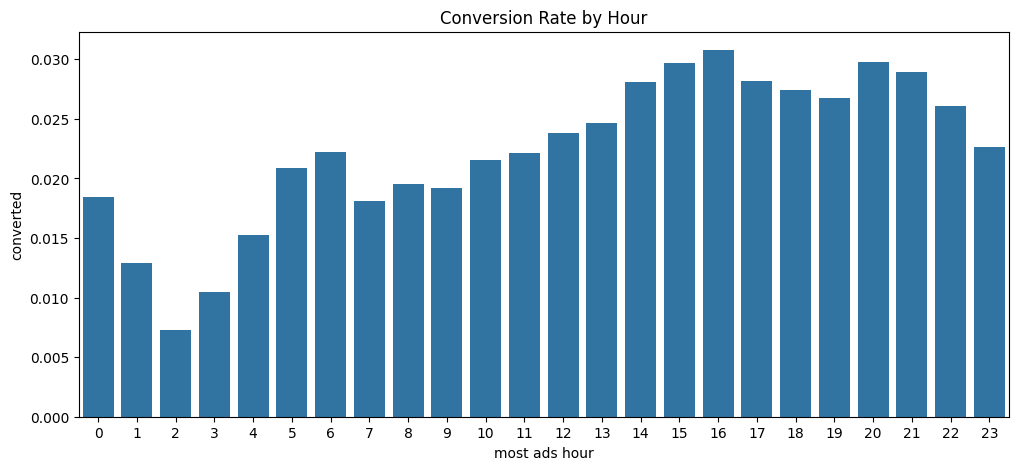

In [34]:
# Строим гистограмму конверсий по часам дня
hour_rate = df.groupby('most ads hour')['converted'].mean().reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data=hour_rate, x='most ads hour', y='converted')
plt.title("Conversion Rate by Hour")
plt.show()

Конверсия явно растёт после полудня и падает к полуночи

Для проверки гипотезы о влиянии показа рекламы на конверсию мы применим следующие методы:
- t-тест
- Дисперсионный анализ ANOVA

#### 3.1 A/B тестирование - сравнение конверсий

**Нулевая гипотеза (H0)**: нет значимой разницы в конверсии между тестовой (ad) и контрольной (psa) группами

In [37]:
import scipy.stats as stats

# Сравниваем конверсии тестовой и контрольной групп с помощью t-теста
control_group = df[df['test group'] == 'psa']
test_group = df[df['test group'] == 'ad']

control_conv = control_group['converted']
test_conv = test_group['converted']

t_stat , p_val = stats.ttest_ind(test_conv , control_conv)

print("t-statistic:", t_stat)
print("P-value:", p_val)

if p_val < 0.05:
    print("Результат: Отвергаем H0 -> Есть статистически значимая разница в конверсиях")
else:
    print("Результат: Не отвергаем H0 -> Нет статистически значимой разницы в конверсиях")

t-statistic: 7.370405974285658
P-value: 1.703305262783145e-13
Результат: Отвергаем H0 -> Есть статистически значимая разница в конверсиях


#### 3.2 Дисперсионный анализ ANOVA - влияет ли день недели на конверсию?

**Нулевая гипотеза (H0)**: день недели НЕ влияет на конверсию

In [38]:
anova_day = stats.f_oneway(*[
    df[df['most ads day'] == day]['converted']
    for day in df['most ads day'].unique()
])

print("ANOVA — День недели")
print("F-statistic:", anova_day.statistic)
print("P-value:", anova_day.pvalue)

if anova_day.pvalue < 0.05:
    print("Результат: Отвергаем H0 -> День недели влияет на конверсию")
else:
    print("Результат: Не отвергаем H0 -> День недели НЕ влияет на конверсию")

ANOVA — День недели
F-statistic: 68.38818386897916
P-value: 1.8032007658145987e-85
Результат: Отвергаем H0 -> День недели влияет на конверсию


#### 3.3 Дисперсионный анализ ANOVA - влияет ли час дня на конверсию?

**Нулевая гипотеза (H0)**: час дня НЕ влияет на конверсию

In [40]:
anova_hour = stats.f_oneway(*[
    df[df['most ads hour'] == hr]['converted']
    for hr in sorted(df['most ads hour'].unique())
])

print("ANOVA — Час дня")
print("F-statistic:", anova_hour.statistic)
print("P-value:", anova_hour.pvalue)

if anova_hour.pvalue < 0.05:
    print("Результат: Отвергаем H0 -> Час дня влияет на конверсию")
else:
    print("Результат: Не отвергаем H0 -> Час дня НЕ влияет на конверсию")

ANOVA — Час дня
F-statistic: 18.742037312974023
P-value: 7.482025334530618e-77
Результат: Отвергаем H0 -> Час дня влияет на конверсию


### 4. Выводы

По итогам тестирования, мы можем утверждать, что:
- Тестовая группа ("ad") имеет более высокую конверсию, чем контрольная ("psa")
- День недели и час дня оказывают статистически значимое влияние на конверсию
- Пиковыми часами для показа рекламы являются промежутки с 10 до 17 часов и с 20 до 22 часов
- Пиковыми днями недели для показа рекламы являются понедельник и вторник

**Главный вывод:** показ рекламы оказывает статистически значимое влияние на конверсию в покупку товара, а команде маркетинга нужно оптимизировать рекламные кампании таким образом, чтобы показ рекламы выпадал на пиковые часы и дни недели.